# **CNN-ViT Hybrid *backbone* EfficientNetB0**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, gc, random, shutil, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score,
                              accuracy_score)
from sklearn.utils import resample
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: []


In [3]:
# konfigurasi path dan hyperparameter
BASE_DIR     = '/content/drive/MyDrive/split'
TRAIN_DIR    = os.path.join(BASE_DIR, 'train')
VALID_DIR    = os.path.join(BASE_DIR, 'valid')
TEST_DIR     = os.path.join(BASE_DIR, 'test')

CKPT_DIR     = '/content/drive/MyDrive/kakao_checkpoint'
CKPT_PATH    = os.path.join(CKPT_DIR, 'best_model.keras')
CKPT_FT_PATH = os.path.join(CKPT_DIR, 'best_model_finetune.keras')
EPOCH_LOG    = os.path.join(CKPT_DIR, 'epoch_log.json')
HISTORY_LOG  = os.path.join(CKPT_DIR, 'history_log.json')

# simpan ke drive agar data augmentasi tidak hilang saat disconnect
BALANCED_DIR = '/content/drive/MyDrive/kakao_checkpoint/balanced_train'

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(BALANCED_DIR, exist_ok=True)

CLASS_NAMES     = sorted(os.listdir(TRAIN_DIR))
IMG_SIZE        = 224
BATCH_SIZE      = 16
EPOCHS          = 50
FINETUNE_EPOCHS = 20
N_CLASSES       = len(CLASS_NAMES)
TARGET_TOTAL    = 750
LR              = 1e-4

print("Kelas:", CLASS_NAMES)
print(f"Jumlah kelas terdeteksi: {len(CLASS_NAMES)}")

Kelas: ['black pod rot', 'healthy', 'helopeltis', 'mealybugs', 'mirid', 'monilia perniciosa (witches broom)', 'moniliophthora roreri (monilia)', 'pod borer']
Jumlah kelas terdeteksi: 8


In [ ]:
# analisis distribusi dataset awal

def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        path = os.path.join(directory, cls)
        if os.path.isdir(path):
            counts[cls] = len([f for f in os.listdir(path)
                                if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return counts

train_counts = count_images(TRAIN_DIR)
print("\nDistribusi TRAIN (sebelum balancing):")
for k, v in train_counts.items():
    print(f"  {k}: {v}")


Distribusi TRAIN (sebelum balancing):
  black pod rot: 660
  healthy: 2340
  helopeltis: 350
  mealybugs: 314
  mirid: 229
  monilia perniciosa (witches broom): 67
  moniliophthora roreri (monilia): 245
  pod borer: 350


In [ ]:
# balancing dataset dengan augmentasi

def get_image_files(class_dir):
    return [os.path.join(class_dir, f) for f in os.listdir(class_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# definisi setiap transform sebagai fungsi terpisah
def flip_horizontal(img):
    return cv2.flip(img, 1)

def flip_vertical(img):
    return cv2.flip(img, 0)

def rotate_90cw(img):
    return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

def rotate_90ccw(img):
    return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

def rotate_180(img):
    return cv2.rotate(img, cv2.ROTATE_180)

def add_gaussian_noise(img, mean=0, sigma_range=(5, 25)):
    """
    Tambahkan Gaussian noise ke gambar.
    sigma dipilih acak dalam sigma_range agar variasi noise berbeda-beda.
    """
    sigma = random.uniform(*sigma_range)
    noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy

# pool semua transform yang tersedia
AUGMENT_POOL = [
    flip_horizontal,
    flip_vertical,
    rotate_90cw,
    rotate_90ccw,
    rotate_180,
    add_gaussian_noise,
]

def augment_image_combined(img, min_transforms=1, max_transforms=3):
    """
    Terapkan KOMBINASI acak beberapa transform sekaligus.
    Jumlah transform dipilih acak antara min_transforms dan max_transforms.
    Urutan transform juga diacak untuk variasi maksimal.

    Contoh kombinasi yang mungkin terjadi:
      - flip_horizontal + gaussian_noise
      - rotate_90cw + flip_vertical + gaussian_noise
      - rotate_180 saja
    """
    n = random.randint(min_transforms, max_transforms)
    chosen = random.sample(AUGMENT_POOL, n)   # tanpa pengulangan
    for transform in chosen:
        img = transform(img)
    return img

# cek balanced dataset
def is_balanced_complete(balanced_dir, class_names, target):
    """Return True hanya jika SEMUA kelas sudah memiliki >= target gambar."""
    if not os.path.exists(balanced_dir):
        return False
    for cls in class_names:
        cls_dir = os.path.join(balanced_dir, cls)
        if not os.path.isdir(cls_dir):
            print(f"  [!] Folder '{cls}' tidak ditemukan.")
            return False
        n = len([f for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        if n < target:
            print(f"  [!] '{cls}' hanya {n}/{target} gambar — belum lengkap.")
            return False
    return True

# bangun balanced dataset
if is_balanced_complete(BALANCED_DIR, CLASS_NAMES, TARGET_TOTAL):
    print("✅ Balanced dataset sudah lengkap di Drive, melewati proses balancing.")
else:
    print("⚠️  Membangun balanced dataset ke Drive (hanya sekali)...")
    if os.path.exists(BALANCED_DIR):
        shutil.rmtree(BALANCED_DIR)
    os.makedirs(BALANCED_DIR, exist_ok=True)

    for cls in CLASS_NAMES:
        src_dir = os.path.join(TRAIN_DIR, cls)
        dst_dir = os.path.join(BALANCED_DIR, cls)
        os.makedirs(dst_dir, exist_ok=True)

        files = get_image_files(src_dir)
        n     = len(files)

        if n >= TARGET_TOTAL:
            # undersampling acak
            selected = resample(files, replace=False, n_samples=TARGET_TOTAL,
                                random_state=SEED)
            for i, fp in enumerate(selected):
                ext = os.path.splitext(fp)[1]
                shutil.copy(fp, os.path.join(dst_dir, f'{cls}_{i:04d}{ext}'))

        else:
            # copy semua gambar asli
            for i, fp in enumerate(files):
                ext = os.path.splitext(fp)[1]
                shutil.copy(fp, os.path.join(dst_dir, f'{cls}_{i:04d}{ext}'))

            # oversampling acak
            needed = TARGET_TOTAL - n
            idx    = 0
            while needed > 0:
                fp  = random.choice(files)
                img = cv2.imread(fp)
                if img is None:
                    continue

                # kombinasi acak 1-3 transform
                img = augment_image_combined(
                    img,
                    min_transforms=1,
                    max_transforms=3
                )

                out_path = os.path.join(dst_dir, f'{cls}_aug_{idx:04d}.jpg')
                cv2.imwrite(out_path, img)
                needed -= 1
                idx    += 1

        n_result = len(get_image_files(dst_dir))
        print(f"  {'✅' if n_result >= TARGET_TOTAL else '❌'} {cls}: {n_result} gambar")

print("\nDistribusi TRAIN (setelah balancing):")
for k, v in count_images(BALANCED_DIR).items():
    flag = "✅" if v >= TARGET_TOTAL else "❌"
    print(f"  {flag} {k}: {v}")

  [!] Folder 'black pod rot' tidak ditemukan.
⚠️  Membangun balanced dataset ke Drive (hanya sekali)...
  ✅ black pod rot: 750 gambar
  ✅ healthy: 750 gambar
  ✅ helopeltis: 750 gambar
  ✅ mealybugs: 750 gambar
  ✅ mirid: 750 gambar
  ✅ monilia perniciosa (witches broom): 750 gambar
  ✅ moniliophthora roreri (monilia): 750 gambar
  ✅ pod borer: 750 gambar

Distribusi TRAIN (setelah balancing):
  ✅ black pod rot: 750
  ✅ healthy: 750
  ✅ helopeltis: 750
  ✅ mealybugs: 750
  ✅ mirid: 750
  ✅ monilia perniciosa (witches broom): 750
  ✅ moniliophthora roreri (monilia): 750
  ✅ pod borer: 750


In [4]:
# data generator
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    BALANCED_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=True, seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    VALID_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print(f"\nTrain steps/epoch : {len(train_gen)}")
print(f"Val   steps/epoch : {len(val_gen)}")
print(f"Test  steps       : {len(test_gen)}")

Found 6000 images belonging to 8 classes.
Found 976 images belonging to 8 classes.
Found 980 images belonging to 8 classes.

Train steps/epoch : 375
Val   steps/epoch : 61
Test  steps       : 62


In [5]:
# CBAM Attention

class ChannelAttention(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        c = input_shape[-1]
        self.gap = layers.GlobalAveragePooling2D()
        self.gmp = layers.GlobalMaxPooling2D()
        self.dense1 = layers.Dense(c // self.ratio, activation='relu', use_bias=False)
        self.dense2 = layers.Dense(c, activation='sigmoid', use_bias=False)
        super().build(input_shape)

    def call(self, x):
        c = tf.shape(x)[-1]
        avg_out = self.dense2(self.dense1(self.gap(x)))   # (B, C)
        max_out = self.dense2(self.dense1(self.gmp(x)))
        out = avg_out + max_out                            # element-wise add
        out = tf.reshape(out, (-1, 1, 1, tf.shape(out)[-1]))
        return x * out


class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv = layers.Conv2D(1, self.kernel_size, padding='same',
                                   activation='sigmoid')
        super().build(input_shape)

    def call(self, x):
        avg_out = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_out = tf.reduce_max(x,  axis=-1, keepdims=True)
        concat  = tf.concat([avg_out, max_out], axis=-1)
        out     = self.conv(concat)
        return x * out


class CBAMBlock(layers.Layer):
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.ch_attn = ChannelAttention(ratio)
        self.sp_attn = SpatialAttention(kernel_size)

    def call(self, x):
        x = self.ch_attn(x)
        x = self.sp_attn(x)
        return x

In [6]:
# Positional Encoding

class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model

    def build(self, input_shape):
        initializer = tf.keras.initializers.RandomNormal(stddev=0.02)
        self.pos_emb = self.add_weight(
            shape=(1, self.seq_len, self.d_model),
            initializer='random_normal', trainable=True, name='pos_enc'
        )

    def call(self, x):
        return x + self.pos_emb

In [7]:
# Transformer Encoder

def transformer_encoder(x, num_heads=8, ff_dim=512, dropout=0.1):
    d_model = x.shape[-1]
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout
    )(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
    ffn = layers.Dense(ff_dim, activation='gelu')(x)
    ffn = layers.Dropout(dropout)(ffn)
    ffn = layers.Dense(d_model)(ffn)
    ffn = layers.Dropout(dropout)(ffn)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)
    return x

In [8]:
# Attention Pooling

class AttentionPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.score_dense = layers.Dense(1)
        super().build(input_shape)

    def call(self, x):
        scores  = self.score_dense(x)              # (B, seq, 1)
        weights = tf.nn.softmax(scores, axis=1)
        out     = tf.reduce_sum(x * weights, axis=1)   # (B, d_model)
        return out

In [9]:
# Build CNN-ViT Model

tf.keras.backend.clear_session()
gc.collect()

def build_cnn_vit(img_size=224, n_classes=8):
    inputs = keras.Input(shape=(img_size, img_size, 3))

    # backbone EfficientNetB0
    backbone = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    backbone.trainable = False
    feat_map = backbone(inputs, training=False) # panggil sebagai sub-model

    # CBAM Attention
    feat_map = CBAMBlock()(feat_map)

    # konversi feature map --> token sequence
    H = feat_map.shape[1]
    W = feat_map.shape[2]
    C = feat_map.shape[3]
    seq_len = H * W
    d_model = 256

    x = layers.Reshape((seq_len, C))(feat_map)
    x = layers.Dense(d_model)(x)
    x = PositionalEncoding(seq_len, d_model)(x)
    x = transformer_encoder(x, num_heads=8, ff_dim=512, dropout=0.1)
    x = transformer_encoder(x, num_heads=8, ff_dim=512, dropout=0.1)
    x = AttentionPooling()(x)

    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='CNN_ViT_Kakao')
    return model

model = build_cnn_vit(IMG_SIZE, N_CLASSES)
model.summary()

# verifikasi backbone
try:
    _ = model.get_layer('efficientnetb0')
    print("✅ Backbone 'efficientnetb0' ditemukan sebagai sub-model.")
except ValueError as e:
    print(f"❌ {e}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CNN_ViT_Kakao"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_block          │ (None, 7, 7,      │    409,699 │ efficientnetb0[0… │
│ (CBAMBlock)         │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 49, 1280)  │          0 │ cbam_block[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 49, 256)   │    327,936 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 49, 256)   │     12,544 │ dense_2[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 256)   │    263,168 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 49, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 256)   │          0 │ positional_encod… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 49, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 49, 512)   │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 49, 512)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 49, 256)   │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 49, 256)   │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 49, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 256)   │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 49, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 49, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,953,935 (22.71 MB)

 Trainable params: 1,904,364 (7.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

✅ Backbone 'efficientnetb0' ditemukan sebagai sub-model.


In [ ]:
# Compile Model

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# resume checkpoint

def load_epoch_log():
    if os.path.exists(EPOCH_LOG):
        with open(EPOCH_LOG) as f:
            return json.load(f)
    return {"stage": "pretrain", "epoch": 0}

def save_epoch_log(stage, epoch):
    with open(EPOCH_LOG, 'w') as f:
        json.dump({"stage": stage, "epoch": epoch}, f)

def load_history_log():
    if os.path.exists(HISTORY_LOG):
        with open(HISTORY_LOG) as f:
            return json.load(f)
    return {}

def save_history_log(hist_dict):
    with open(HISTORY_LOG, 'w') as f:
        json.dump(hist_dict, f)

epoch_log = load_epoch_log()
print(f"Status checkpoint: stage={epoch_log['stage']}, epoch={epoch_log['epoch']}")

if epoch_log['stage'] == 'finetune' and os.path.exists(CKPT_FT_PATH):
    print("Melanjutkan dari checkpoint fine-tune...")
    model.load_weights(CKPT_FT_PATH)
    STAGE = 'finetune'
    INITIAL_EPOCH_FT = epoch_log['epoch']
elif os.path.exists(CKPT_PATH):
    print("Melanjutkan dari checkpoint pretrain...")
    model.load_weights(CKPT_PATH)
    STAGE = 'pretrain'
    INITIAL_EPOCH = epoch_log['epoch']
else:
    print("Tidak ada checkpoint. Training dari awal.")
    STAGE = 'pretrain'
    INITIAL_EPOCH = 0

Status checkpoint: stage=pretrain, epoch=0
Tidak ada checkpoint. Training dari awal.


In [ ]:
best_ckpt = CKPT_FT_PATH if os.path.exists(CKPT_FT_PATH) else CKPT_PATH
model.load_weights(best_ckpt)
print(f"✅ Berhasil memuat model dari: {best_ckpt}")

✅ Berhasil memuat model dari: /content/drive/MyDrive/kakao_checkpoint/best_model_finetune.keras


In [ ]:
# callback helper

class EpochLogger(keras.callbacks.Callback):
    """Simpan epoch terakhir ke disk setiap akhir epoch."""
    def __init__(self, stage):
        super().__init__()
        self.stage = stage
    def on_epoch_end(self, epoch, logs=None):
        save_epoch_log(self.stage, epoch + 1)

In [ ]:
# pre-train - tahap 1 - backbone frozen

if STAGE == 'pretrain':
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=7,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7, verbose=1),
        ModelCheckpoint(CKPT_PATH, monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        EpochLogger('pretrain'),  # [NEW]
    ]

    history = model.fit(
        train_gen,
        steps_per_epoch=len(train_gen),
        validation_steps=len(val_gen),
        validation_data=val_gen,
        epochs=EPOCHS,
        initial_epoch=INITIAL_EPOCH,
        callbacks=callbacks, # [FIX 3]
        verbose=1
    )

    # history jika disconnect saat train
    hist_dict = load_history_log()
    hist_dict['pretrain'] = history.history
    save_history_log(hist_dict)

    save_epoch_log('finetune', 0)  # tandai siap masuk fase fine-tune
    STAGE = 'finetune'
    INITIAL_EPOCH_FT = 0
else:
    print("Stage pretrain sudah selesai, melewati...")
    history = None

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5013 - loss: 1.3416
Epoch 1: val_accuracy improved from None to 0.85963, saving model to /content/drive/MyDrive/kakao_checkpoint/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/kakao_checkpoint/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 1493s 4s/step - accuracy: 0.6562 - loss: 0.9463 - val_accuracy: 0.8596 - val_loss: 0.3905 - learning_rate: 1.0000e-04
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8349 - loss: 0.4767
Epoch 2: val_accuracy improved from 0.85963 to 0.89447, saving model to /content/drive/MyDrive/kakao_checkpoint/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/kakao_checkpoint/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 695s 2s/step - accuracy: 0.8383 - loss: 0.4690 - val_accuracy: 0.8945 - val_loss: 0.2789 - learning_rate: 1.0000e-04
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8697 - loss: 0.3701
Epoch 3: val_

In [ ]:
# tahap 2 - fine-tuning

backbone_layer = model.get_layer('efficientnetb0')

# unfreeze 20 layer terakhir
for layer in backbone_layer.layers[:-20]:
    layer.trainable = False
for layer in backbone_layer.layers[-20:]:
    layer.trainable = True

# hitung berapa layer yang trainable
trainable_count = sum(1 for l in backbone_layer.layers if l.trainable)
print(f"Backbone trainable layers: {trainable_count} / {len(backbone_layer.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-8, verbose=1),
    ModelCheckpoint(CKPT_FT_PATH, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EpochLogger('finetune'),
]

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINETUNE_EPOCHS,
    initial_epoch=INITIAL_EPOCH_FT,
    callbacks=callbacks_ft,
    verbose=1
)

# simpan history fine-tune
hist_dict = load_history_log()
hist_dict['finetune'] = history_ft.history
save_history_log(hist_dict)

Backbone trainable layers: 20 / 238
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8791 - loss: 0.3569
Epoch 1: val_accuracy improved from None to 0.90984, saving model to /content/drive/MyDrive/kakao_checkpoint/best_model_finetune.keras

Epoch 1: finished saving model to /content/drive/MyDrive/kakao_checkpoint/best_model_finetune.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 791s 2s/step - accuracy: 0.8917 - loss: 0.3100 - val_accuracy: 0.9098 - val_loss: 0.2938 - learning_rate: 1.0000e-05
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9170 - loss: 0.2374
Epoch 2: val_accuracy did not improve from 0.90984
375/375 ━━━━━━━━━━━━━━━━━━━━ 751s 2s/step - accuracy: 0.9153 - loss: 0.2440 - val_accuracy: 0.9088 - val_loss: 0.2874 - learning_rate: 1.0000e-05
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9308 - loss: 0.2012
Epoch 3: val_accuracy improved from 0.90984 to 0.91393, saving model to /content/drive/MyDrive/kakao_checkpoint/best_model_finetun

In [ ]:
# evaluasi

best_ckpt = CKPT_FT_PATH if os.path.exists(CKPT_FT_PATH) else CKPT_PATH
model.load_weights(best_ckpt)

test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

print("\n=== Evaluation Report ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_true, y_pred, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

62/62 ━━━━━━━━━━━━━━━━━━━━ 801s 13s/step

=== Evaluation Report ===
Accuracy : 0.9255
Precision: 0.9259
Recall   : 0.9255
F1-Score : 0.9254

Classification Report:
                                    precision    recall  f1-score   support

                     black pod rot       0.82      0.83      0.83       142
                           healthy       0.95      0.95      0.95       502
                        helopeltis       0.90      0.99      0.94        75
                         mealybugs       0.97      0.91      0.94        68
                             mirid       0.94      0.88      0.91        50
monilia perniciosa (witches broom)       0.85      0.73      0.79        15
   moniliophthora roreri (monilia)       0.96      0.98      0.97        53
                         pod borer       0.92      0.91      0.91        75

                          accuracy                           0.93       980
                         macro avg       0.91      0.90      0.90       98

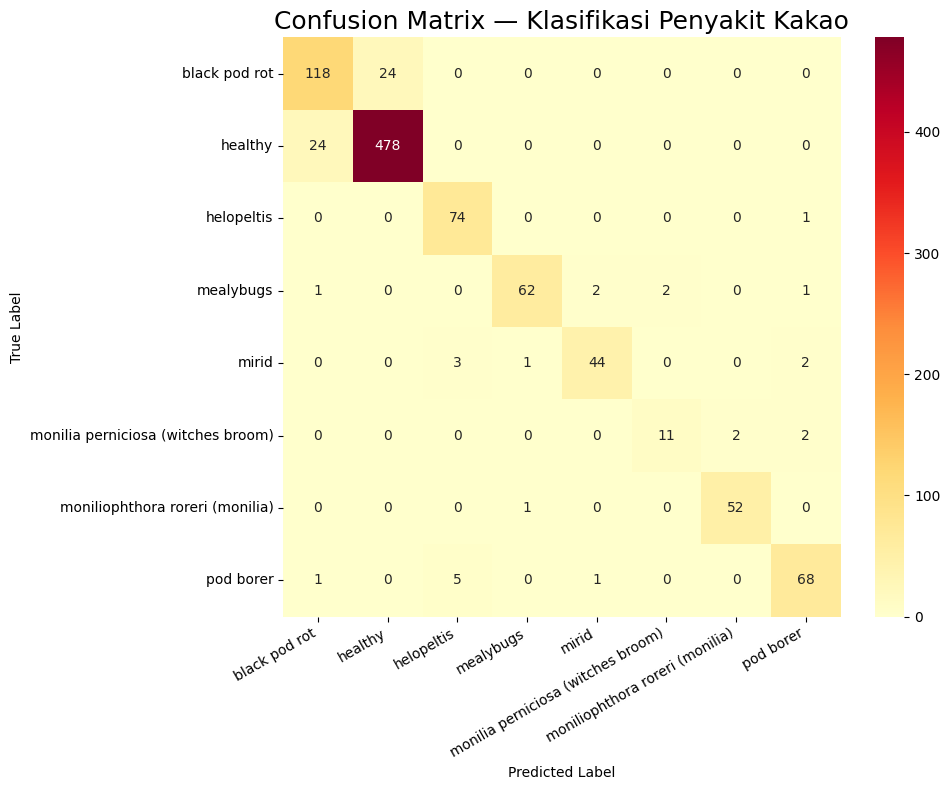

✅ Confusion matrix berhasil dibuat dan disimpan!


In [13]:
# confusion matrix
# 1. Tarik ulang kunci jawaban (Instan, 0 detik)
if 'y_true' not in locals() or 'y_true' not in globals():
    y_true = test_gen.classes

# cek apakah y_pred masih tersimpan di RAM Colab
if 'y_pred' not in locals() or 'y_pred' not in globals():
    print("⚠️ y_pred tidak terdeteksi di memori RAM!")
    best_ckpt = CKPT_FT_PATH if os.path.exists(CKPT_FT_PATH) else CKPT_PATH
    model.load_weights(best_ckpt)

    test_gen.reset()
    y_pred_prob = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_gen.classes

# buat gambar confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Klasifikasi Penyakit Kakao', fontsize=18)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print("✅ Confusion matrix berhasil dibuat dan disimpan!")

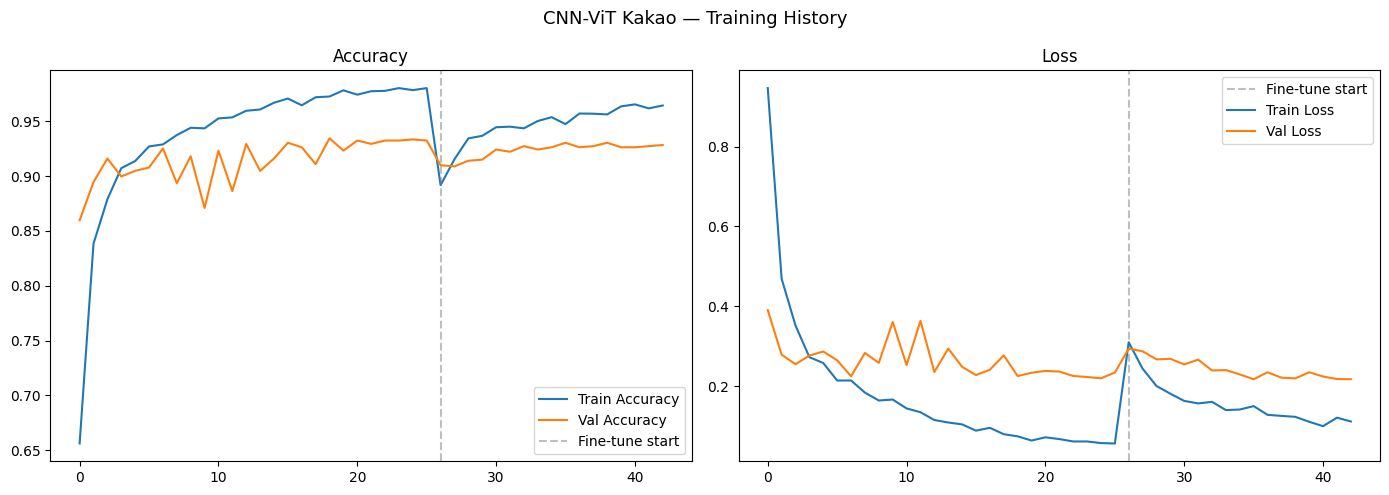


=== Analisis Overfitting/Underfitting ===
✅ Model generalisasi baik. Gap train-val = 3.61%.


In [ ]:
# plt train history

def plot_history_from_log(hist_log_path):
    hist_dict = load_history_log()
    acc, val_acc, loss, val_loss = [], [], [], []

    for stage in ['pretrain', 'finetune']:
        if stage in hist_dict:
            h = hist_dict[stage]
            acc      += h.get('accuracy', [])
            val_acc  += h.get('val_accuracy', [])
            loss     += h.get('loss', [])
            val_loss += h.get('val_loss', [])

    if not acc:
        print("History log kosong — tidak ada yang diplot.")
        return

    epochs_range = range(len(acc))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs_range, acc,     label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    if 'pretrain' in hist_dict and 'finetune' in hist_dict:
        split = len(hist_dict['pretrain'].get('accuracy', []))
        axes[0].axvline(split, color='gray', linestyle='--', alpha=0.5, label='Fine-tune start')
        axes[1].axvline(split, color='gray', linestyle='--', alpha=0.5, label='Fine-tune start')
    axes[0].set_title('Accuracy'); axes[0].legend()
    axes[1].plot(epochs_range, loss,     label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    axes[1].set_title('Loss'); axes[1].legend()
    plt.suptitle('CNN-ViT Kakao — Training History', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, 'training_history.png'), dpi=150)
    plt.show()

    final_gap = abs(val_acc[-1] - acc[-1])
    print("\n=== Analisis Overfitting/Underfitting ===")
    if acc[-1] < 0.75 and val_acc[-1] < 0.75:
        print("⚠️  UNDERFITTING: Akurasi train & val rendah.")
    elif final_gap > 0.10:
        print(f"⚠️  OVERFITTING: Gap train-val = {final_gap:.2%}.")
    else:
        print(f"✅ Model generalisasi baik. Gap train-val = {final_gap:.2%}.")

plot_history_from_log(HISTORY_LOG)

[INFO] Grad-CAM Target Layer: cbam_block


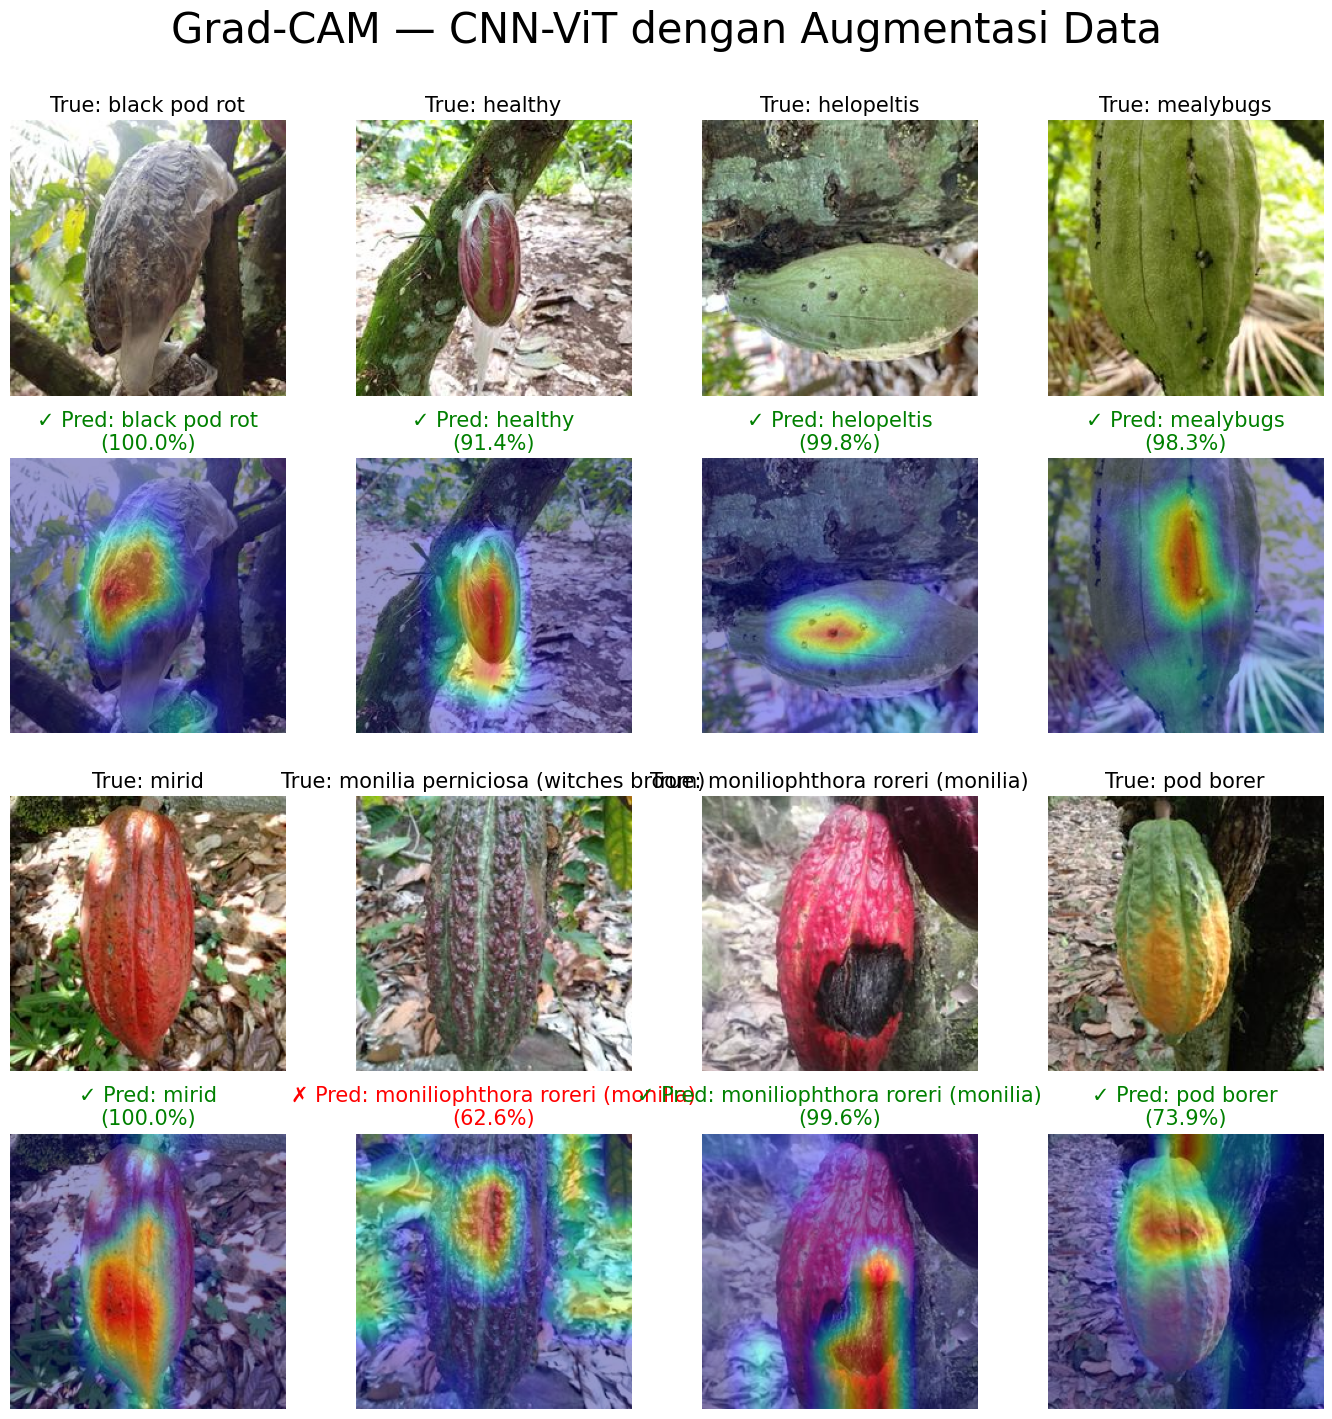

✅ Saved: /content/drive/MyDrive/kakao_checkpoint/gradcam_sample_random.png


In [ ]:
# Frad-CAM

import matplotlib.cm as cm

def build_gradcam_model(model):
    target_layer = None
    for layer in model.layers:
        if 'cbam' in layer.name.lower():
            target_layer = layer
            break

    if target_layer is None:
        target_layer = model.layers[2]

    print(f"[INFO] Grad-CAM Target Layer: {target_layer.name}")

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[target_layer.output, model.output],
        name='gradcam_model'
    )
    return grad_model


def make_gradcam_heatmap(img_array, grad_model, pred_index=None):
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        feat_map, predictions = grad_model(img_tensor, training=False)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, feat_map)

    if grads is None:
        raise ValueError("Gradien None — Keras gagal melacak topologi graf.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = feat_map[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)

    heatmap_max = tf.math.reduce_max(heatmap)
    if heatmap_max != 0:
        heatmap = heatmap / heatmap_max

    return heatmap.numpy(), int(pred_index), predictions.numpy()[0]


def overlay_gradcam(img_input, heatmap, alpha=0.4):
    if isinstance(img_input, str):
        img = cv2.imread(img_input)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = np.uint8(np.clip(img_input, 0, 255))

    img             = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    return cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)


import random

def visualize_gradcam(model, test_gen, class_names, cols=4):
    grad_model = build_gradcam_model(model)

    n_samples = len(class_names)
    rows = (n_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows * 2, cols, figsize=(cols * 3.5, rows * 7))
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    # Kelompokkan semua nomor indeks gambar berdasarkan kelasnya
    class_indices = {i:[] for i in range(len(class_names))}
    for i, label in enumerate(test_gen.classes):
        class_indices[label].append(i)

    # pilih dari masing-masing kelas
    # chosen_indices = [random.choice(class_indices[i]) for i in range(len(class_names))]
    chosen_indices = [class_indices[i][0] for i in range(len(class_names))]

    # ambil gambar dari test_gen berdasarkan indeks yang terpilih
    all_images = []
    all_labels =[]
    for idx in chosen_indices:
        batch_num = idx // test_gen.batch_size
        item_num  = idx % test_gen.batch_size

        batch_x, batch_y = test_gen[batch_num]

        all_images.append(batch_x[item_num])
        all_labels.append(np.argmax(batch_y[item_num]))

    # proses Grad-CAM
    correct = 0
    for idx in range(n_samples):
        row_top = (idx // cols) * 2
        row_bot = row_top + 1
        col     = idx % cols

        img_array  = np.expand_dims(all_images[idx], axis=0)
        true_label = all_labels[idx]

        try:
            heatmap, pred_label, preds = make_gradcam_heatmap(img_array, grad_model)
            cam_img    = overlay_gradcam(all_images[idx], heatmap)
            confidence = float(preds[pred_label]) * 100
            cam_ok     = True

        except Exception as e:
            print(f"[WARN] Sampel {idx}: {e}")
            cam_img    = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            pred_label = 0
            confidence = 0.0
            cam_ok     = False

        is_correct = cam_ok and (pred_label == true_label)
        if is_correct:
            correct += 1

        axes[row_top][col].imshow(all_images[idx].astype('uint8'))
        axes[row_top][col].set_title(
            f"True: {class_names[true_label]}", fontsize=15)
        axes[row_top][col].axis('off')

        axes[row_bot][col].imshow(cam_img)
        color  = 'green' if is_correct else 'red'
        status = '✓' if is_correct else '✗'
        axes[row_bot][col].set_title(
            f"{status} Pred: {class_names[pred_label]}\n({confidence:.1f}%)",
            fontsize=15, color=color
        )
        axes[row_bot][col].axis('off')

    acc_sample = correct / n_samples * 100
    plt.suptitle(
        f'Grad-CAM — CNN-ViT dengan Augmentasi Data',
        fontsize=30, y=1.01
    )
    plt.tight_layout()
    out_path = os.path.join(CKPT_DIR, 'gradcam_sample_random.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {out_path}")

visualize_gradcam(model, test_gen, CLASS_NAMES, cols=4)

In [ ]:
# end

print("\n" + "="*55)
print("TRAINING SELESAI")
print("="*55)
print(f"Best pretrain checkpoint : {CKPT_PATH}")
print(f"Best fine-tune checkpoint: {CKPT_FT_PATH}")
print(f"Epoch log                : {EPOCH_LOG}")
print(f"History log              : {HISTORY_LOG}")
print(f"Confusion Matrix         : {CKPT_DIR}/confusion_matrix.png")
print(f"Training History         : {CKPT_DIR}/training_history.png")
print(f"Grad-CAM Sample          : {CKPT_DIR}/gradcam_sample.png")


TRAINING SELESAI
Best pretrain checkpoint : /content/drive/MyDrive/kakao_checkpoint/best_model.keras
Best fine-tune checkpoint: /content/drive/MyDrive/kakao_checkpoint/best_model_finetune.keras
Epoch log                : /content/drive/MyDrive/kakao_checkpoint/epoch_log.json
History log              : /content/drive/MyDrive/kakao_checkpoint/history_log.json
Confusion Matrix         : /content/drive/MyDrive/kakao_checkpoint/confusion_matrix.png
Training History         : /content/drive/MyDrive/kakao_checkpoint/training_history.png
Grad-CAM Sample          : /content/drive/MyDrive/kakao_checkpoint/gradcam_sample.png
